Introduction:

Banks analyze customer transaction data to understand spending behavior, identify patterns, and improve financial services.

This project analyzes simulated transaction data to explore:

• Spending patterns across categories

• Transaction behavior across time

• Distribution of transaction amounts

• Customer spending trends

Tools Used:
Python, Pandas, NumPy, Matplotlib, Seaborn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)

transactions = pd.DataFrame({
    "Customer_ID": np.random.randint(1000,1050,600),
    "Amount": np.random.randint(10,600,600),
    "Category": np.random.choice(
        ["Food","Shopping","Travel","Bills","Entertainment"],
        600
    ),
    "Hour": np.random.randint(0,24,600)
})

transactions.head()

,Customer_ID,Amount,Category,Hour
0,1038,71,Food,12
1,1028,351,Shopping,22
2,1014,406,Travel,14
3,1042,28,Food,10
4,1007,186,Food,9


The dataset contains simulated financial transactions including customer ID, transaction amount, spending category, and transaction hour.


In [3]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Customer_ID  600 non-null    int64 
 1   Amount       600 non-null    int64 
 2   Category     600 non-null    object
 3   Hour         600 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 18.9+ KB


In [4]:
transactions.describe()

,Customer_ID,Amount,Hour
count,600.000000,600.000000,600.000000
mean,1025.085000,287.600000,11.226667
std,14.246615,171.129577,6.953359
min,1000.000000,10.000000,0.000000
25%,1013.000000,140.500000,5.000000
50%,1026.000000,275.500000,11.000000
75%,1036.000000,433.250000,17.000000
max,1049.000000,599.000000,23.000000


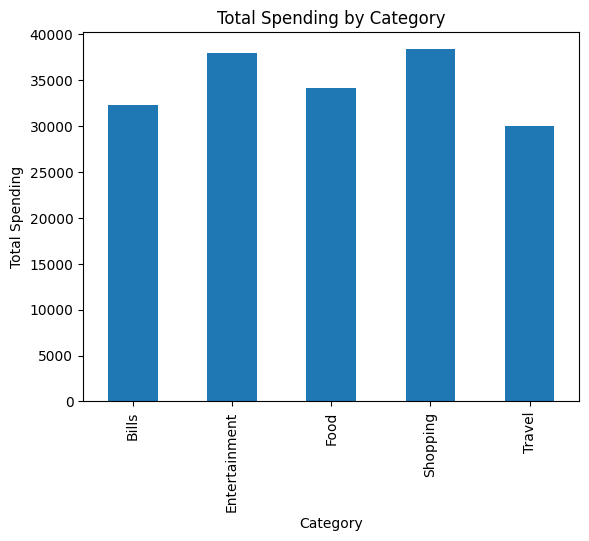

In [5]:
transactions.groupby("Category")["Amount"].sum().plot(kind="bar")

plt.title("Total Spending by Category")
plt.xlabel("Category")
plt.ylabel("Total Spending")

plt.show()

Insight:

The chart shows how spending is distributed across different categories. Categories such as shopping and bills typically account for a larger portion of customer expenditures.


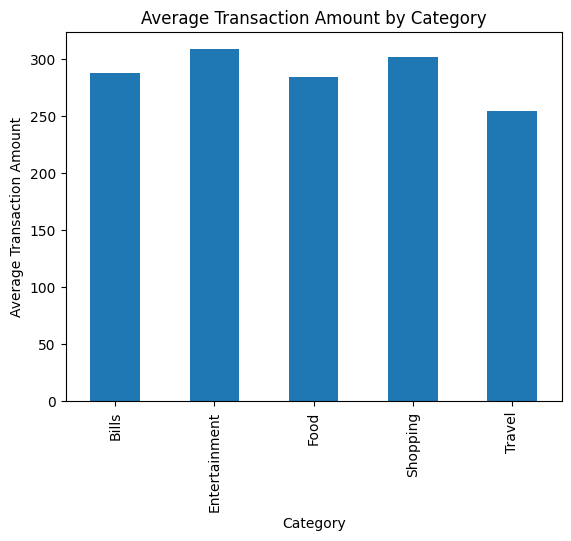

In [6]:
transactions.groupby("Category")["Amount"].mean().plot(kind="bar")

plt.title("Average Transaction Amount by Category")
plt.xlabel("Category")
plt.ylabel("Average Transaction Amount")

plt.show()

Insight:

Average transaction value varies across spending categories. Travel and entertainment transactions often involve higher average spending.


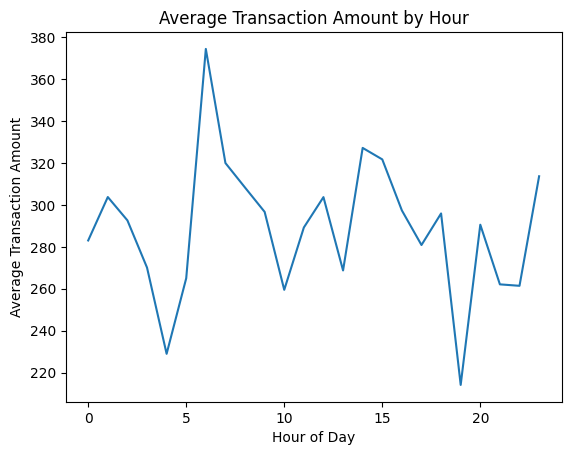

In [7]:
transactions.groupby("Hour")["Amount"].mean().plot()

plt.title("Average Transaction Amount by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Transaction Amount")

plt.show()

Insight:

Transaction activity changes throughout the day. Evening hours often show higher spending due to shopping and leisure activities.


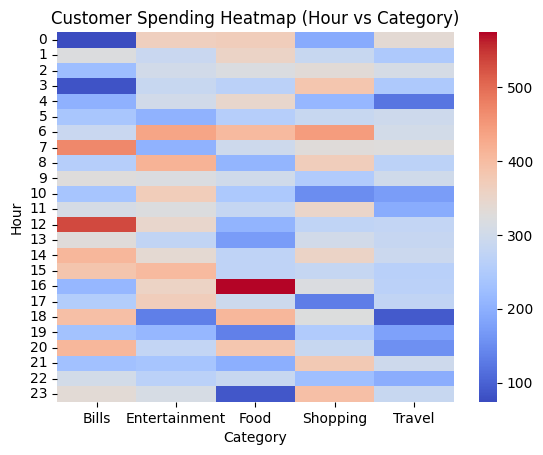

In [8]:
pivot = transactions.pivot_table(
    values="Amount",
    index="Hour",
    columns="Category",
    aggfunc="mean"
)

sns.heatmap(pivot, cmap="coolwarm")

plt.title("Customer Spending Heatmap (Hour vs Category)")

plt.show()

Insidight:

The heatmap highlights how spending varies across categories and time of day. Such visualizations help financial institutions understand customer activity patterns.


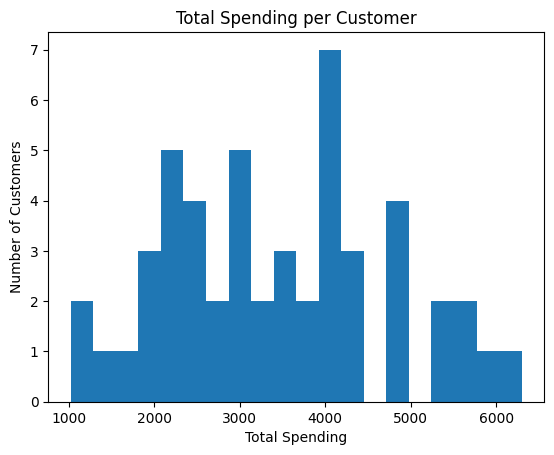

In [9]:
customer_spending = transactions.groupby("Customer_ID")["Amount"].sum()

plt.hist(customer_spending, bins=20)

plt.title("Total Spending per Customer")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.show()

Insight:

Customer spending varies significantly, indicating the presence of both low-spending and high-spending customer segments.


In [10]:
customer_spending = transactions.groupby("Customer_ID")["Amount"].sum()

customer_spending.head()

,Amount
Customer_ID,
1000,4273
1001,5393
1002,2904
1003,3041
1004,3450


In [11]:
segments = pd.cut(
    customer_spending,
    bins=[0,2000,5000,10000],
    labels=["Low Spender","Medium Spender","High Spender"]
)

In [12]:
segments.value_counts()

,count
Amount,
Medium Spender,38
Low Spender,6
High Spender,6


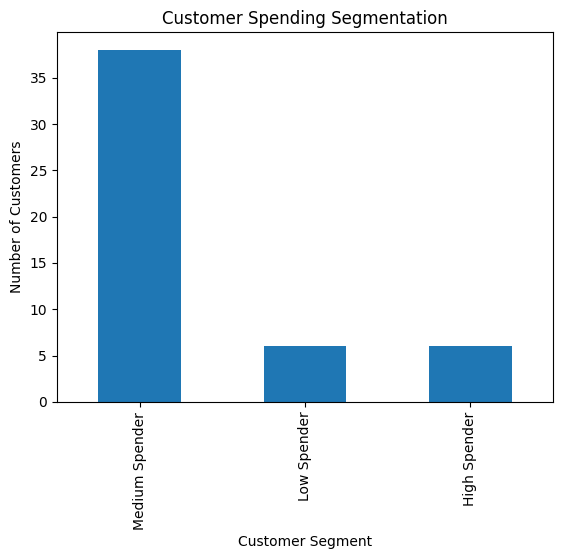

In [13]:
segments.value_counts().plot(kind="bar")

plt.title("Customer Spending Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

Customer segmentation reveals distinct spending groups within the customer base. Most customers fall into the low-to-medium spending category, while a smaller group represents high-value customers. Financial institutions can use such insights to design targeted financial products and personalized marketing strategies.

Conclusion

This project analyzed customer transaction data to understand spending behavior and identify meaningful patterns in financial activity. The analysis revealed that spending varies significantly across different categories, with certain categories such as shopping and bills accounting for a larger share of total expenditures.

Transaction patterns also change throughout the day, indicating that customer activity is influenced by time-based behavioral trends. The distribution of transaction amounts shows that most purchases fall within moderate spending ranges, while higher-value transactions occur less frequently.

Customer segmentation further highlights differences in spending behavior, identifying groups of low, medium, and high spenders. Such segmentation is valuable for financial institutions, as it allows banks to better understand their customer base and design targeted financial products, personalized offers, and risk management strategies.

Overall, the project demonstrates how transaction data can be used to generate actionable insights about customer behavior. Data-driven analysis like this helps financial institutions improve customer engagement, optimize services, and make informed business decisions.
